In [9]:
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend

def load_private_key_from_file(file_path):
    with open(file_path, "rb") as key_file:
        private_key = serialization.load_pem_private_key(
            key_file.read(),
            password=None,  # or provide a password if your key is encrypted
            backend=default_backend()
        )
    return private_key

In [10]:
import base64
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import padding, rsa
from cryptography.exceptions import InvalidSignature

def sign_pss_text(private_key: rsa.RSAPrivateKey, text: str) -> str:
    message = text.encode('utf-8')
    try:
        signature = private_key.sign(
            message,
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH
            ),
            hashes.SHA256()
        )
        return base64.b64encode(signature).decode('utf-8')
    except InvalidSignature as e:
        raise ValueError("RSA sign PSS failed") from e

In [11]:
import requests
import datetime

current_time = datetime.datetime.now()
timestamp = current_time.timestamp()
current_time_milliseconds = int(timestamp * 1000)
timestampt_str = str(current_time_milliseconds)

private_key = load_private_key_from_file('Key1.txt')

method = "GET"
base_url = 'https://external-api.kalshi.com'
path='/trade-api/v2/portfolio/balance'

# Strip query parameters from path before signing
path_without_query = path.split('?')[0]
msg_string = timestampt_str + method + path_without_query
sig = sign_pss_text(private_key, msg_string)

headers = {
    'KALSHI-ACCESS-KEY': '982c924c-9e22-44c8-a801-3be1ff50d45d',
    'KALSHI-ACCESS-SIGNATURE': sig,
    'KALSHI-ACCESS-TIMESTAMP': timestampt_str
}

response = requests.get(base_url + path, headers=headers)

print(response.text)

{"balance":927,"balance_breakdown":[{"balance":"9.2759","exchange_index":0}],"balance_dollars":"9.2759","portfolio_value":582,"updated_ts":1782097109}


In [12]:
import requests

# Get orderbook for a specific market
event_ticker = "KXATP-26EASTBO" 
url = f"https://external-api.kalshi.com/trade-api/v2/events/{event_ticker}?with_milestones=True"

response = requests.get(url)
temp = response.json()

temp

{'event': {'available_on_brokers': True,
  'category': 'Sports',
  'collateral_return_type': 'MECNET',
  'event_ticker': 'KXATP-26EASTBO',
  'last_updated_ts': '0001-01-01T00:00:00Z',
  'mutually_exclusive': True,
  'product_metadata': {'competition': 'ATP Eastbourne',
   'competition_scope': 'Game'},
  'series_ticker': 'KXATP',
  'settlement_sources': [{'name': 'Fox Sports',
    'url': 'https://www.foxsports.com'},
   {'name': 'ESPN', 'url': 'https://www.espn.com'},
   {'name': 'ATP', 'url': 'https://www.atptour.com/'}],
  'strike_period': '',
  'sub_title': '2026 ATP Eastbourne',
  'title': 'ATP Eastbourne Final: Bergs vs Humbert'},
 'markets': [{'can_close_early': True,
   'close_time': '2026-06-25T18:05:33Z',
   'created_time': '2026-06-23T22:00:32.524772Z',
   'custom_strike': {'tennis_competitor': 'b28a9833-6b29-487a-bbff-fcfab9e79d9b'},
   'early_close_condition': 'This market will close and expire after a winner is declared.',
   'event_ticker': 'KXATP-26EASTBO',
   'expected_e

In [1]:
import requests

# Get orderbook for a specific market
market_ticker = "KXWCGAME-26JUN23COLCOD-COL"
url = f"https://external-api.kalshi.com/trade-api/v2/markets/{market_ticker}/orderbook"

response = requests.get(url)
orderbook_data = response.json()

orderbook_data

{'orderbook_fp': {'no_dollars': [], 'yes_dollars': []}}

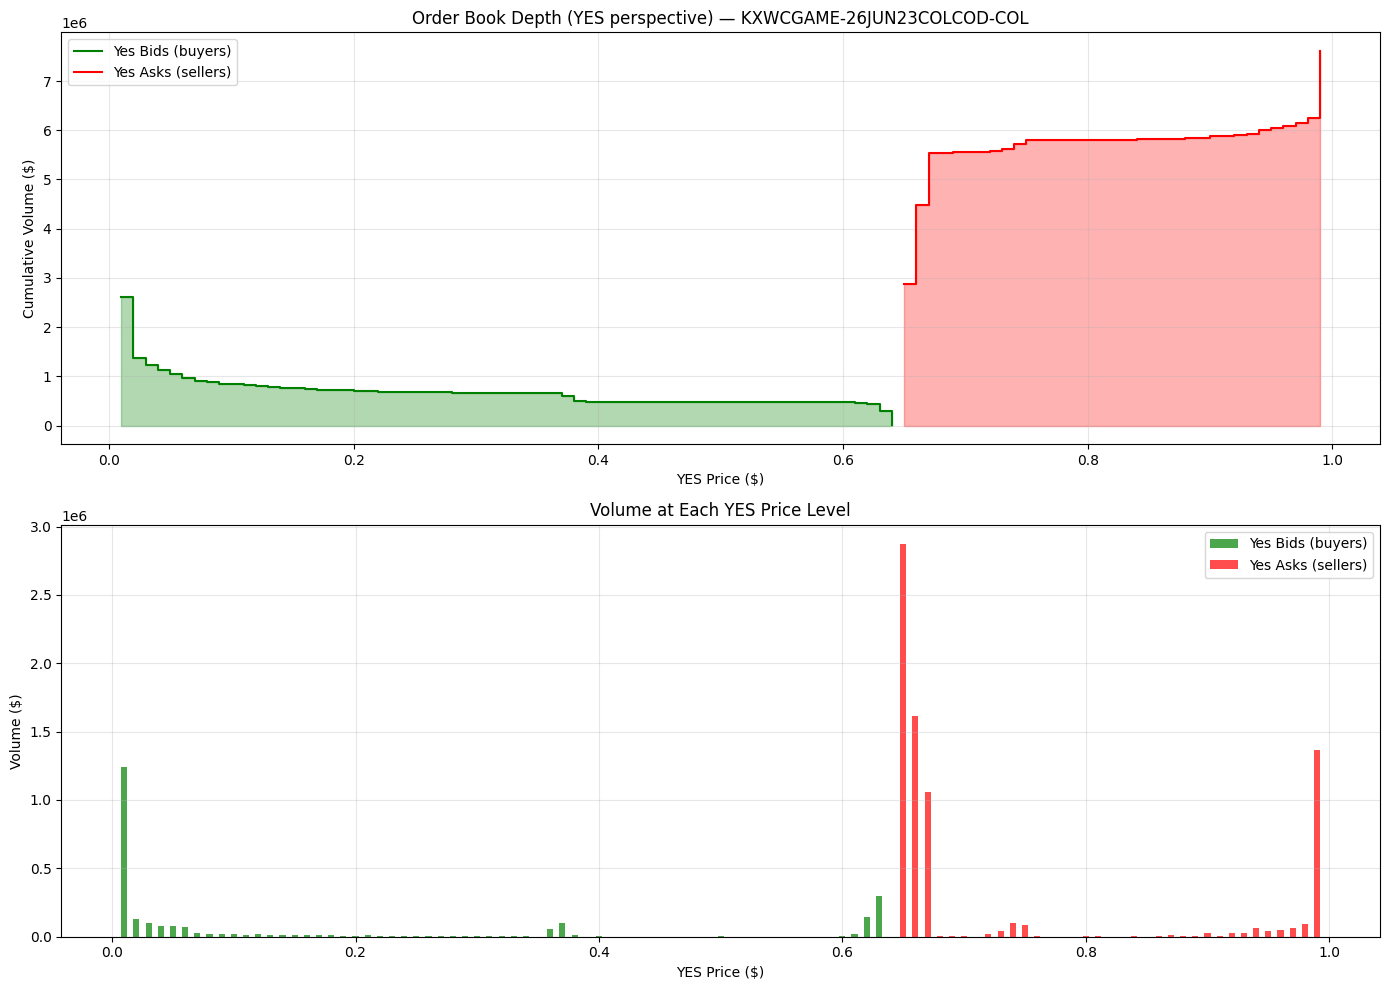


--- YES Asks near $0.90 (people selling YES / buying NO) ---
 YES Ask Price     Volume ($)
$        0.85 $     1,029.53
$        0.86 $     3,522.46
$        0.87 $    11,239.47
$        0.88 $     5,320.46
$        0.89 $     8,091.89
$        0.90 $    30,763.04
$        0.91 $     5,838.28
$        0.92 $    25,916.68
$        0.93 $    27,802.04
$        0.94 $    65,593.88
$        0.95 $    38,281.36
$        0.96 $    47,800.07
$        0.97 $    62,203.59
$        0.98 $    95,746.09
$        0.99 $ 1,365,732.11


In [10]:
import matplotlib.pyplot as plt
import numpy as np

ob = orderbook_data['orderbook_fp']

# Yes bids: people wanting to BUY yes at this price
yes_bid_prices = [float(p) for p, v in ob['yes_dollars']]
yes_bid_vols = [float(v) for p, v in ob['yes_dollars']]

# No bids flipped: a no bid at X = someone willing to SELL yes at (1-X)
yes_ask_prices = [1 - float(p) for p, v in ob['no_dollars']]
yes_ask_vols = [float(v) for p, v in ob['no_dollars']]
# Sort asks low to high
sorted_asks = sorted(zip(yes_ask_prices, yes_ask_vols))
yes_ask_prices = [p for p, v in sorted_asks]
yes_ask_vols = [v for p, v in sorted_asks]

# Cumulative depth: bids accumulate from high to low, asks from low to high
bid_cum = np.cumsum(yes_bid_vols[::-1])[::-1]
ask_cum = np.cumsum(yes_ask_vols)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# --- Depth chart (YES perspective) ---
ax1.fill_between(yes_bid_prices, bid_cum, alpha=0.3, color='green', step='post')
ax1.step(yes_bid_prices, bid_cum, where='post', color='green', lw=1.5, label='Yes Bids (buyers)')
ax1.fill_between(yes_ask_prices, ask_cum, alpha=0.3, color='red', step='post')
ax1.step(yes_ask_prices, ask_cum, where='post', color='red', lw=1.5, label='Yes Asks (sellers)')
ax1.set_xlabel('YES Price ($)')
ax1.set_ylabel('Cumulative Volume ($)')
ax1.set_title(f'Order Book Depth (YES perspective) — {market_ticker}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Volume bars ---
bar_w = 0.005
ax2.bar(yes_bid_prices, yes_bid_vols, width=bar_w, color='green', alpha=0.7, label='Yes Bids (buyers)')
ax2.bar(yes_ask_prices, yes_ask_vols, width=bar_w, color='red', alpha=0.7, label='Yes Asks (sellers)')
ax2.set_xlabel('YES Price ($)')
ax2.set_ylabel('Volume ($)')
ax2.set_title('Volume at Each YES Price Level')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the ask side near 0.90 so you can see exact numbers
print("\n--- YES Asks near $0.90 (people selling YES / buying NO) ---")
print(f"{'YES Ask Price':>14} {'Volume ($)':>14}")
for p, v in sorted_asks:
    if 0.85 <= p <= 0.99:
        print(f"${p:>12.2f} ${v:>13,.2f}")